In [11]:
#import the necessary packages
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd

# Name: 
# Date:

Add anything else for indentification/or however you want to label this notebook up here before submitting. 

# Submission
You do not need to write up a separate report since there will be space for you to write down thoughts/answer questions throughout this notebook. Instead, when you are finished, go to File --> Save and Export Notebook As --> LaTeX (or as pdf, but this option hasn't been working). This will convert the notebook to a .tex file which can be uploaded into Overleaf which will compile into a already formatted pdf. 

Chi Squared
-
Equation for it:
$$\chi^{2} = \sum_{i=1}^{N}{\frac{(y_{i}^{OBS}-y_{i}^{MOD})^{2}}{\epsilon_{y_{i}}^{2}}}$$
where $y_{i}^{OBS}$ are the data/observations with error estimation $\epsilon_{y_{i}}$, and $y_{i}^{MOD}$ is the model function.

Reduced Chi-Squared
-
It is also necessary to know the number of degrees of freedom of our model $\nu$ when we derive the $\chi^{2}$, where for $n$ data points and $p$ fit parameters, the number of degrees of freedom is $\chi^{2} = n-p$. Therefore, we define a reduced $\chi^{2}$ as 
$$\chi^{2}_{\nu} = \frac{\chi^{2}}{\nu}$$
where $\nu = n-m$ with $n$ = number of measurements and $p$ = number of fitted parameters.

To determine how well the model has fit the data, we use the reduced $\chi^{2}_{\nu}$:
- $\chi^{2}_{\nu} < 1 \rightarrow$ over-fitting of the data
- $\chi^{2}_{\nu} > 1 \rightarrow$ poor model fit
- $\chi^{2}_{\nu} \simeq 1 \rightarrow$ good match between data and model in accordance with the data error

Taken from: https://events.mpifr-bonn.mpg.de/indico/event/30/material/slides/12.pdf (Section 2.3)

## Simple power law

To get started, download Simple_Data.csv. It's some fake noisy data that forms a power law to help ensure that your code is working. 

The goal is to explore how $\chi^{2}$ explores the parameter space for two parameters (A and k), and one parameter (fix A, vary k or fix k, vary A) by making a brute force $\chi^{2}$ algorithm. 

The model for this problem is the power law which takes the functional form
$$y = Ax^{k}$$
where $A$ is a constant and $k$ is the exponent (or power law index). 

The first thing to do is make some functions for the model, $\chi^{2}$, and $\chi^{2}_{\nu}$.

In [35]:
#this was just for the random data file that I made - it does not need to be done by our classmates
np.random.seed(42) #just so I get the same values as I repeat the procedure as a check to make sure things work

#power law params
A = 5        
alpha = -1.7 
x = np.linspace(1, 100, 100) #range of x values 
y_true = A*x**alpha #eqn without noise

noise = np.random.normal(0, 0.20 * y_true) #noise

y = y_true + noise #the equation I want the model to fit to
y_err = 0.2*y_true #just some errors 

#Into dataframe
df = pd.DataFrame({"x": x,"y": y,"y_err": y_err}) #this will be saved as a file for later - want to play around with this some more

df.to_csv("Simple_Data.csv",index=False)

In [40]:
data = pd.read_csv("Simple_Data.csv")

In [19]:
def chi_square(data,model,error):
    chi = (data-model)**2/error**2
    return np.sum(chi)

def reduced_chi(chi,n,m):
    v = n - m
    return chi/v

def powerlaw(a,k,x):
    return a*x**k

### Two parameter fit 
Start with the two parameter fit in which for each combination of $A$ and $k$, a $\chi^{2}$ and $\chi^{2}_{\nu}$ is computed. Hint: define a grid of values of both parameters for $\chi^{2}$ to search through. Mess around with them to try and get a low $\chi^{2}_{\nu}$.

Print out some of these values for a few of the iterations to see how they change. Comment on what you notice.

Note: This is a brute force method that explores the whole defined parameter space. It does not try and get the lowest-chi squre value.

In [20]:
#need to search through a grid of values to find a and k
a_grid = np.linspace(1, 10, 200)
k_grid = np.linspace(-3, 0, 200)

chi2_grid = np.zeros((len(a_grid), len(k_grid))) #this is where the chi-square will fill in
redchi2_grid = np.zeros((len(a_grid), len(k_grid))) #this is where the reduced chi-square will fill in

#two parameter fit
for i, a in enumerate(a_grid): #want to attach an index to make it easier to find the best fit at the end
    for j, k in enumerate(k_grid): #want to attach an index to make it easier to find the best fit at the end

        model = powerlaw(a, k, x)

        chi2 = chi_square(y, model, y_err)
        chi2_grid[i, j] = chi2

        chi2_red = reduced_chi(chi2, len(x), 2)
        redchi2_grid[i, j] = chi2_red

        if i % 70 == 0 and j % 70 == 0:
            print(f"a={a:.3f}, k={k:.3f}, chi2={chi2:.2f}, red_chi2={chi2_red:.2f}")     

a=1.000, k=-3.000, chi2=2447.86, red_chi2=24.98
a=1.000, k=-1.945, chi2=2082.97, red_chi2=21.25
a=1.000, k=-0.889, chi2=47111.01, red_chi2=480.72
a=4.166, k=-3.000, chi2=2366.84, red_chi2=24.15
a=4.166, k=-1.945, chi2=1082.73, red_chi2=11.05
a=4.166, k=-0.889, chi2=1078808.85, red_chi2=11008.25
a=7.332, k=-3.000, chi2=2311.99, red_chi2=23.59
a=7.332, k=-1.945, chi2=467.24, red_chi2=4.77
a=7.332, k=-0.889, chi2=3463829.01, red_chi2=35345.19


Comments: Sometimes the same a values are used for different k's as the parameter space is explored. It really is checking every set of parameters. Some of the $\chi^{2}_{\nu}$ is really high indicating a poor fit, but there are a few that are a lot lower. The best  $\chi^{2}_{\nu}$ I see is 4.77. The $\chi^{2}$ value fluctuates a lot depending on the parameters used. 

Now, find and report the lowest value of $\chi^{2}_{\nu}$ and the corresponding $\chi^{2}$, $A$, and $k$. These are your best fit parameters. 

In [21]:
#getting the best values
idx = np.unravel_index(np.argmin(redchi2_grid), redchi2_grid.shape)
a_best = a_grid[idx[0]]
k_best = k_grid[idx[1]]
chi2_min = chi2_grid[idx]
redchi2_min = redchi2_grid[idx]

print("Best-fit a:", a_best)
print("Best-fit k:", k_best)
print("Chi-square:", chi2_min)
print("Reduced chi-square:", redchi2_min)

Best-fit a: 4.9798994974874375
Best-fit k: -1.7035175879396987
Chi-square: 81.61709511099002
Reduced chi-square: 0.8328275011325512


Plot the data with errors, model with the best-fit parameters, and residuals in log-log space (should see a line). Comment on the fit.

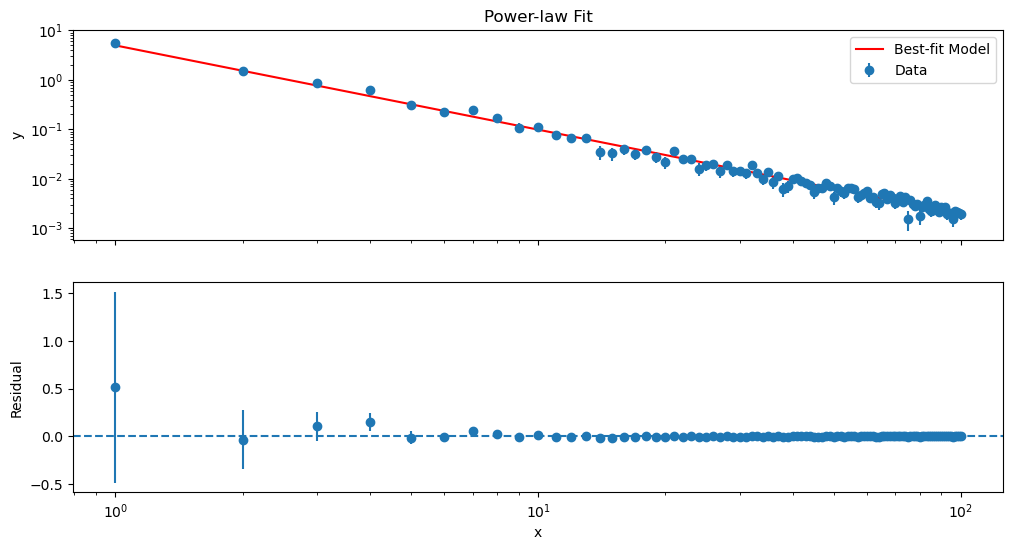

In [22]:
#plot it up in loglog - should see a line
model_best = powerlaw(a_best, k_best, x) #what does the model look like with the best params
residuals = y - model_best #calc residuals 

fig, ax = plt.subplots(2, 1, figsize=(12,6), sharex=True)

ax[0].errorbar(x, y, yerr=y_err, fmt="o", label="Data")
ax[0].plot(x, model_best, color="red", label="Best-fit Model")
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_ylabel("y")
ax[0].set_title("Power-law Fit")
ax[0].legend()

ax[1].errorbar(x, residuals, yerr=y_err, fmt="o")
ax[1].axhline(0, linestyle="--")
ax[1].set_xscale("log")
ax[1].set_xlabel("x")
ax[1].set_ylabel("Residual")
plt.show()

Comments: I think the model fits the data fairly well, especially towards larger values of x. It doesn't do as well in the beginning of the dataset, so I would agree with the $\chi^{2}_{\nu}$ = 0.833. Technically, this model is underfitting the data, but it's close enough to 1 that it's okay. 

We can also see how how $\chi^{2}$ changes as it cycles through the different combinations of parameters. Comment on the parameter space in relation to thest best-fit values. To do this, make a contour plot of $A$ vs $k$ with a colorbar indicating $\chi^{2}$. 

Hint: Use LogNorm for the colorbar. The plot should look choppy if you have a low grid resolution, this is fine. If you want, you can make a finer grid, but that will very quickly make the $\chi^{2}$ search become more computationally expensive. 

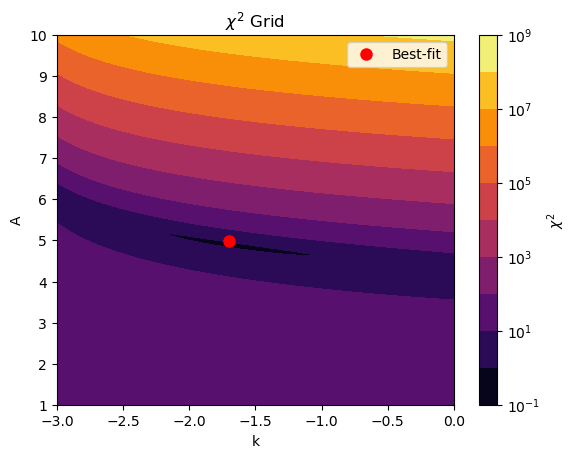

In [23]:
cp = plt.contourf(k_grid, a_grid, redchi2_grid.T, levels=10, cmap="inferno", norm=LogNorm())
plt.colorbar(cp, label=r"$\chi^{2}$")

plt.plot(k_best, a_best, 'ro', markersize=8, label="Best-fit")
plt.xlabel("k")
plt.ylabel("A")
plt.title(r"$\chi^{2}$ Grid")
plt.legend()
plt.show()

Comments: High values of A across the whole span of k are not good parameters, but as the value of A decreases, the $\chi^{2}$ decreases too. It looks like there is a large range of k values that are acceptable, especially at lower values of A. It looks like my best-fit lies right in where $\chi^{2}$ is lowest which is good. That means the brute force method is working properly. 

Note
-
It might be beneficial for our classmates to zoom in on the best fit area to see how well the red dot actually looks within this parameter space. 

### Single parameter fit
What happens if we fix one of the parameters and let $\chi^{2}$ search for the other? Either fix $A$ and vary $k$, fix $k$ and vary $A$, or do both.

Again, to start, you want to define a grid space for the parameter you will search for and set one of your parameters as a constant. Feel free to experiment with this. If you want, print out a few values like before. 

#### Fixing k, search A
This is the "answers" if students fix the value of k and search for A. 

In [24]:
k_fixed = -1 #fix k
a_grid = np.linspace(-20, 20, 200) #Explore a

chi2_grid_a = np.zeros(len(a_grid)) #this is where the chi-square will fill in
redchi2_grid_a = np.zeros(len(a_grid)) #this is where the reduced chi-square will fill in

#one parameter fit
for i, a in enumerate(a_grid):
    model = powerlaw(a, k_fixed, x)
    
    chi2 = chi_square(y, model, y_err)
    chi2_grid_a[i] = chi2

    chi2_red = reduced_chi(chi2, len(x), 1) #only one dof since fixed a 
    redchi2_grid_a[i] = chi2_red

    if i % 20 == 0:
            print(f"a={a:.3f}, k={k_fixed:.3f}, chi2={chi2:.2f}, red_chi2={chi2_red:.2f}")  

a=-20.000, k=-1.000, chi2=10937430.16, red_chi2=110479.09
a=-15.980, k=-1.000, chi2=7030254.71, red_chi2=71012.67
a=-11.960, k=-1.000, chi2=3983051.73, red_chi2=40232.85
a=-7.940, k=-1.000, chi2=1795821.23, red_chi2=18139.61
a=-3.920, k=-1.000, chi2=468563.20, red_chi2=4732.96
a=0.101, k=-1.000, chi2=1277.66, red_chi2=12.91
a=4.121, k=-1.000, chi2=393964.59, red_chi2=3979.44
a=8.141, k=-1.000, chi2=1646624.00, red_chi2=16632.57
a=12.161, k=-1.000, chi2=3759255.89, red_chi2=37972.28
a=16.181, k=-1.000, chi2=6731860.26, red_chi2=67998.59


Now, find and report the lowest value of $\chi^{2}_{\nu}$ and the corresponding $\chi^{2}$, $A$, and $k$. These are your best fit parameters. Compare your results of the two parameter search vs one parameter search.

In [25]:
idx_min = np.argmin(redchi2_grid_a)
a_best = a_grid[idx_min]
chi2_min = chi2_grid_a[idx_min]
redchi2_min = redchi2_grid_a[idx_min]

print("Fixed k =", k_fixed)
print("Best-fit A =", a_best)
print("Chi-square =", chi2_min)
print("Reduced chi-square =", redchi2_min)

Fixed k = -1
Best-fit A = 0.30150753768844396
Chi-square = 487.660349665212
Reduced chi-square = 4.925862117830424


Comments: Based on the $\chi_{\nu}^{2}$ the fit isn't as good as the two parameter search. This makes sense because I am limiting the parameter space a lot more than before, so it can only do its best within my defined parameters. 

Plot the minimum $\chi^{2}$ for one parameter by doing $\chi^{2}$ - $\chi^{2}_{min}$ vs parameter. Also, draw a line at the value of the best fit parameter. Comment on what this plot means.

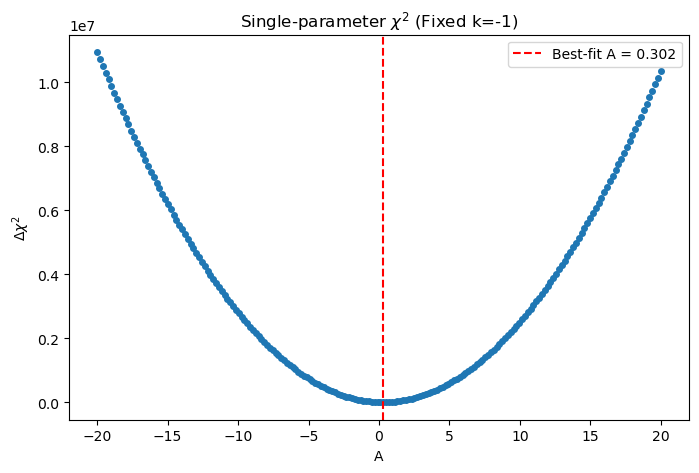

In [26]:
delta_chi2 = chi2_grid_a - chi2_grid_a.min() 

plt.figure(figsize=(8,5))
plt.plot(a_grid, delta_chi2, 'o', markersize=4)
plt.axvline(a_best, color='red', linestyle='--', label=f'Best-fit A = {a_best:.3f}')
plt.xlabel("A")
plt.ylabel(r"$\Delta \chi^2$")
plt.title(rf"Single-parameter $\chi^{2}$ (Fixed k={k_fixed})")
plt.legend()
plt.show()

Comments: For fixing k and letting A vary, the curve forms a parabola, so it's trying to find the lowest $\chi^{2}$ given its parameters. Most values of A do not work for this dataset because as you move further out from the best-fit, the $\chi^{2}$ gets worse quickly. 

#### Single parameter fit - k
This is the "answers" if students fix the value of A and search for k. 

In [27]:
a_fixed = 3 #fix a 
k_grid = np.linspace(-6, 3, 200) #explore k

chi2_grid_k = np.zeros(len(k_grid)) #this is where the chi-square will fill in
redchi2_grid_k = np.zeros(len(k_grid)) #this is where the chi-square will fill in

#one parameter fit
for i, k in enumerate(k_grid):
    model = powerlaw(a_fixed, k, x)
    
    chi2 = chi_square(y, model, y_err)
    chi2_grid_k[i] = chi2

    chi2_red = reduced_chi(chi2, len(x), 1) #only one dof since fixed a 
    redchi2_grid_k[i] = chi2_red

    if i % 20 == 0:
            print(f"a={a_fixed:.3f}, k={k:.3f}, chi2={chi2:.2f}, red_chi2={chi2_red:.2f}")  

a=3.000, k=-6.000, chi2=2452.98, red_chi2=24.78
a=3.000, k=-5.095, chi2=2450.72, red_chi2=24.75
a=3.000, k=-4.191, chi2=2444.52, red_chi2=24.69
a=3.000, k=-3.286, chi2=2419.09, red_chi2=24.44
a=3.000, k=-2.382, chi2=2173.48, red_chi2=21.95
a=3.000, k=-1.477, chi2=624.09, red_chi2=6.30
a=3.000, k=-0.573, chi2=8815410.39, red_chi2=89044.55
a=3.000, k=0.332, chi2=24387463895.37, red_chi2=246338019.15
a=3.000, k=1.236, chi2=75278413719886.19, red_chi2=760388017372.59
a=3.000, k=2.141, chi2=249546449524846432.00, red_chi2=2520671207321681.00


Now, find and report the lowest value of $\chi^{2}_{\nu}$ and the corresponding $\chi^{2}$, $A$, and $k$. These are your best fit parameters. Compare your results of the two parameter search vs one parameter search.

In [28]:
idx_min = np.argmin(redchi2_grid_k)
k_best = k_grid[idx_min]
chi2_min = chi2_grid_k[idx_min]
redchi2_min = redchi2_grid_k[idx_min]

print("Fixed a =", a_fixed)
print("Best-fit k =", k_best)
print("Chi-square =", chi2_min)
print("Reduced chi-square =", redchi2_min)

Fixed a = 3
Best-fit k = -1.5678391959798992
Chi-square = 113.43330090082645
Reduced chi-square = 1.1457909181901662


Comments: Looking at $\chi^{2}_{\nu}$, the fit is actually pretty good even though one of the parameters is fixed. I feel like this is unexpected, but if I fix this value based on the best-fit parameters from the two parameter search, this makes a little more sense.

Plot the minimum $\chi^{2}$ for one parameter by doing $\chi^{2}$ - $\chi^{2}_{min}$ vs parameter. Also, draw a line at the value of the best fit parameter. Comment on what this plot means.

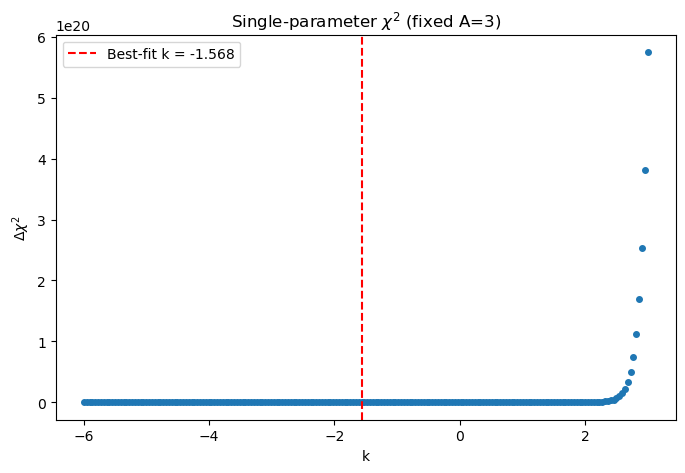

In [30]:
delta_chi2 = chi2_grid_k - chi2_grid_k.min()
k_min = k_grid[np.argmin(delta_chi2)]

plt.figure(figsize=(8,5))
plt.plot(k_grid, delta_chi2, 'o', markersize=4)
plt.axvline(k_best, color='red', linestyle='--', label=f'Best-fit k = {k_best:.3f}')
plt.xlabel("k")
plt.ylabel(r"$\Delta \chi^2$")
plt.title(rf"Single-parameter $\chi^{2}$ (fixed A={a_fixed})")
plt.legend()
plt.show()

Comments: There is a wide range of acceptable values for the power law index for $A = 3$. As the values of k get a lot higher, $\chi^{2}$ gets worse very fast.

## Real Data
Now let's apply what we've done from before to some real data. Download Stellar_Data.txt which holds stellar age (years), mass ($M_{\odot}$), accretion rate ($M_{\odot}/yr$), and accretion rate errors. Note: the data is already in log scale, so how will that change your model function?

In [49]:
data = pd.read_csv("Stellar_Data.txt", delimiter="\t")
data.columns = data.columns.str.strip() #get rid of the white space from txt file column headers

mass = data["Mstar"]
logage = data["logAge"]
logmacc = data["logMacc"]
err = data["logMaccErr"]

In [50]:
def linear_model(m, b, x):
    return m*x+b

Use the brute force method for two parameters from before. Play around with your parameter space and print out some parameters, $\chi^{2}$, and $\chi^{2}_{\nu}$. Comment on what you notice about these values.

In [51]:
m_grid = np.linspace(-10, 0, 200)   
b_grid = np.linspace(-10, 0, 200)    

chi2_grid = np.zeros((len(a_grid), len(b_grid)))
redchi2_grid = np.zeros((len(a_grid), len(b_grid)))

for i, m in enumerate(m_grid):
    for j, b in enumerate(b_grid):
        model_vals = linear_model(m, b, logage)
        chi2 = chi_square(logmacc, model_vals, err)
        chi2_grid[i, j] = chi2
        
        chi2_red = reduced_chi(chi2, len(logage), 2)
        redchi2_grid[i, j] = chi2_red

        if i % 80 == 0 and j % 80 == 0:
            print(f"m={m:.3f}, b={b:.3f}, chi2={chi2:.2f}, red_chi2={chi2_red:.2f}")     

m=-10.000, b=-10.000, chi2=151663004.04, red_chi2=578866.43
m=-10.000, b=-5.980, chi2=133821125.85, red_chi2=510767.66
m=-10.000, b=-1.960, chi2=117104085.13, red_chi2=446962.16
m=-5.980, b=-10.000, chi2=56874759.31, red_chi2=217079.23
m=-5.980, b=-5.980, chi2=46162265.36, red_chi2=176191.85
m=-5.980, b=-1.960, chi2=36574608.88, red_chi2=139597.74
m=-1.960, b=-10.000, chi2=7683281.83, red_chi2=29325.50
m=-1.960, b=-5.980, chi2=4100172.11, red_chi2=15649.51
m=-1.960, b=-1.960, chi2=1641899.86, red_chi2=6266.79


Comments: Again, I see it exploring every set of parameter combinations possible. This took longer than the one from before. Why? I also don't see that much of an improvement from the values I'm printing out. Why could this be the case?

Now, find and report the lowest value of $\chi^{2}_{\nu}$, the corresponding $\chi^{2}$, and the corresponding parameters. These are your best fit parameters. Note: for this dataset, do not expect a low $\chi^{2}_{\nu}$ because of how spread out the data is.

In [52]:
#getting the best values
idx = np.unravel_index(np.argmin(redchi2_grid), redchi2_grid.shape)
m_best = m_grid[idx[0]]
b_best = b_grid[idx[1]]
chi2_min = chi2_grid[idx]
redchi2_min = redchi2_grid[idx]

print("Best-fit m:", m_best)
print("Best-fit b:", b_best)
print("Chi-square:", chi2_min)
print("Reduced chi-square:", redchi2_min)

Best-fit m: -0.8040201005025125
Best-fit b: -2.5125628140703515
Chi-square: 27189.81988279683
Reduced chi-square: 103.77793848395737


As before, plot the data with errors, model with the best-fit parameters, and residuals (should see a line). Comment on the fit. Don't forget your units!

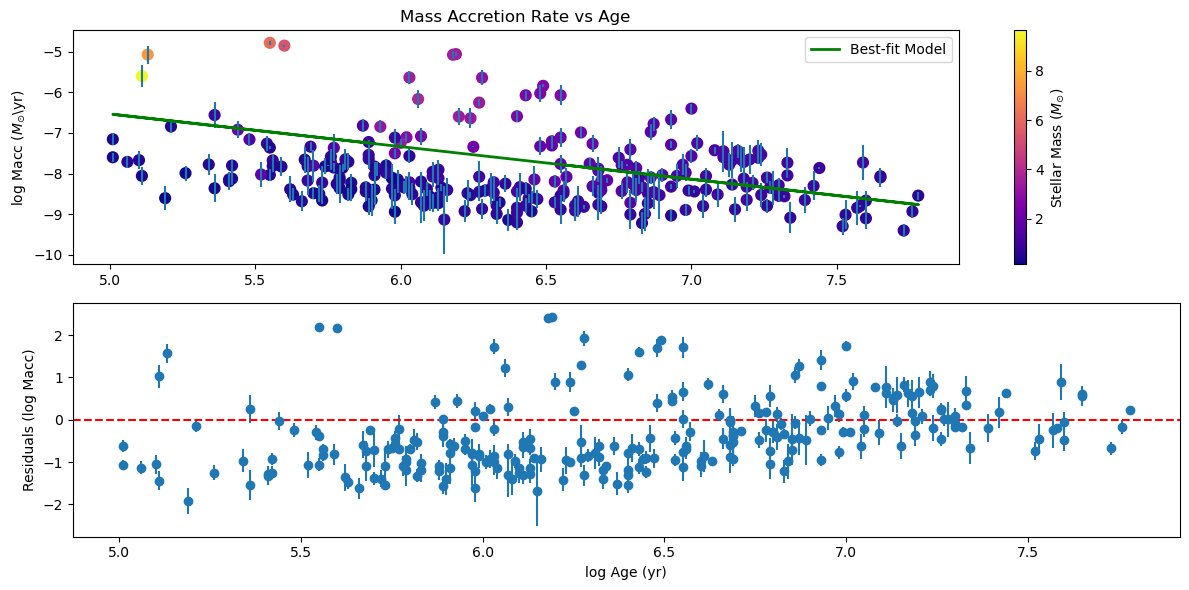

In [53]:
model_best = linear_model(m_best, b_best, logage)
residuals = logmacc - model_best

fig, ax = plt.subplots(2, 1, figsize=(12,6), sharex=False)

sc = ax[0].scatter(logage, logmacc, c=mass, cmap="plasma", s=60)
ax[0].errorbar(logage, logmacc, yerr=err, fmt='none')
ax[0].plot(logage, model_best, color="green", lw=2, label="Best-fit Model")
ax[0].set_ylabel(r"log Macc ($M_{\odot}$\yr)")
ax[0].set_title("Mass Accretion Rate vs Age")
ax[0].legend()
cbar = plt.colorbar(sc, ax=ax[0])
cbar.set_label(r"Stellar Mass ($M_{\odot}$)")

ax[1].errorbar(logage, residuals, yerr=err, fmt="o")
ax[1].axhline(0, linestyle="--", color="red")
ax[1].set_xlabel("log Age (yr)")
ax[1].set_ylabel("Residuals (log Macc)")

plt.tight_layout()
plt.show()

Comments: From the residuals and $\chi^{2}_{\nu}$ = 103.8, the fit is not that great. There is a wide spread in values such that the model is not enough to make the fit look perfect. However, that is the trend of the data, so it's good enough.

Also, make the contour plot of parameter 1 vs parameter 2 with a colorbar indicating $\chi^{2}$ again. Comment on the parameter space in relation to these best-fit values. 

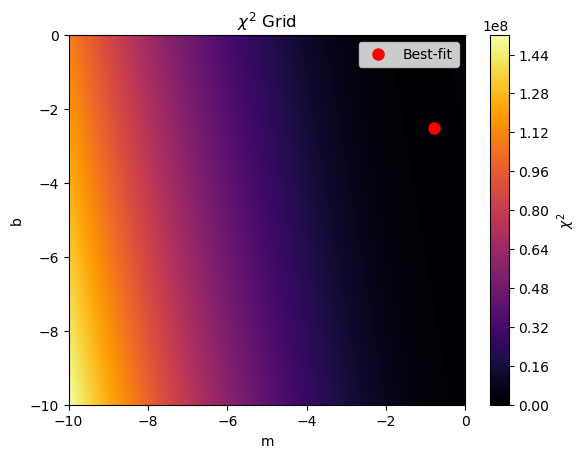

In [55]:
cp = plt.contourf(m_grid, b_grid, chi2_grid.T, levels=200, cmap="inferno")
plt.colorbar(cp, label=r"$\chi^{2}$")

plt.plot(m_best, b_best, 'ro', markersize=8, label="Best-fit")
plt.xlabel("m")
plt.ylabel("b")
plt.title(r"$\chi^{2}$ Grid")
plt.legend()
plt.show()

Comments: $\chi^{2}$ values are most acceptable at low values of m across many values of b. 

# Fitting Stellar Accretion
Use the emcee package to run MCMC on a data set for stellar accretion
https://emcee.readthedocs.io/en/stable/
Follow the steps in https://prappleizer.github.io/Tutorials/MCMC/MCMC_Tutorial_Solution.html to set up the MCMC, but use the power law you used in Question 1 for your model. 

In [1]:
import emcee
import pandas as pd
import numpy as np

In [2]:
df = pd.read_table('Stellar_Data.txt')
df.columns = df.columns.str.strip()
df

,Mstar,logAge,logMacc,logMaccErr
0,1.931,6.57,-8.082,0.225
1,1.802,6.69,-8.268,0.457
2,1.612,6.86,-8.097,0.161
3,1.616,6.90,-8.036,0.174
4,0.759,5.99,-8.195,0.285
...,...,...,...,...
259,0.656,5.92,-7.888,0.173
260,0.490,6.45,-8.933,0.145
261,1.055,6.60,-8.914,0.266
262,1.271,7.24,-7.533,0.289


<Axes: xlabel='logAge', ylabel='logMacc'>

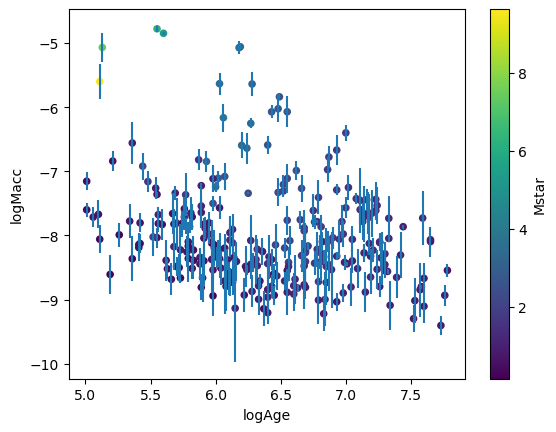

In [3]:
df.plot.scatter(x = 'logAge', y = 'logMacc', c = 'Mstar', yerr = 'logMaccErr', colormap='viridis') #added error bars

In [8]:
#defining power law model - since the data is already log scale, the model is just a line
def model(theta, x):
    m, b = theta
    return m*x+b

#defining the log likelihood
def lnlike(theta, x, y, yerr):
    model_y = model(theta, x)
    sigma2 = yerr**2
    return -0.5 * np.sum((y - model_y)**2/ sigma2 + np.log(sigma2))

#defining the lnprior
def lnprior(theta):
    m, b = theta
    if -10 < m < 20 and -5 < b < 5: #I'm cheating here from the chi-square bit above, but the ranges here should include the best fits from above
        #otherwise MCMC won't be able to do it
        return 0.0
    return -np.inf

#defining the posterior probability 
def lnprob(theta, x, y, yerr):
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike(theta, x, y, yerr)

In [5]:
x = df['logAge']
y = df['logMacc']
yerr = df['Mstar']
nwalkers = 128
niter = 500

initial = np.array([1,1])
ndim = len (initial)
p0 = np.array(initial) + 1e-4 * np.random.randn(nwalkers,ndim)

In [6]:
def main(p0, nwalkers, niter, ndim, lnprob, x, y, yerr):
    sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob, args=(x, y, yerr))
    
    print("Running burn-in...")
    p0, _, _ = sampler.run_mcmc(p0, 100)
    sampler.reset()

    print("Running production...")
    pos, prob, state = sampler.run_mcmc(p0, niter)

    return sampler, pos, prob, state


In [7]:
sampler, pos, prob, state = main(p0,nwalkers,niter,ndim,lnprob,x, y, yerr)

Running burn-in...
Running production...


In [9]:
def plotter(sampler, x = x, y = y, yerr = yerr):
    plt.ion()
    plt.errorbar(x, y, yerr=yerr, fmt = 'o', label = 'Data', alpha = 0.6)
    samples = sampler.get_chain(discard = 100, thin= 10, flat = True)
    inds = np.random.randint(len(samples), size=100)
    for i in inds:
        theta = samples[i]
        plt.plot(x, model(theta, x), color="r", alpha=0.1)

    # Best-fit line (median parameters)
    A_mcmc, alpha_mcmc = np.median(samples, axis=0)
    plt.plot(x, model([A_mcmc, alpha_mcmc], x), color='black', label='Best fit')

    plt.xlabel('logAge')
    plt.ylabel('logMacc')
    plt.legend()
    plt.show()

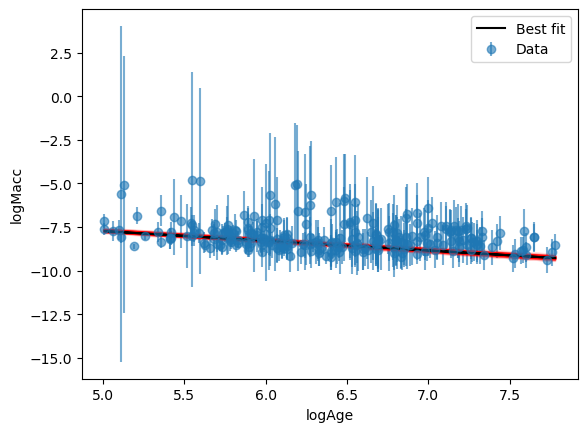

In [13]:
plotter(sampler) #now it loks much better

Comments: